# Predicting combined-stress impact in plants with the authors' trained ANN

**Paper:** Priya P. et al., *An artificial neural network-based deep learning model to predict combined stress impact and interaction in plants*, **Applications in Plant Sciences** 14(2):e70047 (2026). DOI: [10.1002/aps3.70047](https://doi.org/10.1002/aps3.70047) (PMC13103545)

**Author code:** https://github.com/scipdatabase/Prediction_model (pinned `main`, verified 2026-09-29)

## Purpose and scope
This notebook runs the **authors' published trained model** on a minimal example: given a plant species, a stress combination and its intensities (45 encoded features), the composite ANN predicts (1) which morphological/yield **parameter** is affected (classification) and (2) the **plant performance** (% reduction vs control, regression).

What this notebook does:
1. Downloads the authors' trained Keras model (`tanh_best_model.keras`), label encoder and example data from the authors' GitHub repository.
2. Runs the authors' exact `model_prediction.py` inference flow on their `example.csv`.
3. Compares predictions with the authors' shipped `Real_output.csv`.
4. Predicts a small rice scenario (Control / Drought / Heat / Drought+Heat) built from the repository README.

What this notebook does **NOT** do (out of scope): retraining the model (the training notebook `Combined_stress.ipynb` and `X_train.csv`/`y_train.csv` referenced in the README are **not present** in the repository), dataset-scale evaluation, or the paper's rice greenhouse experiment. A single-example run does not verify the paper's reported 76.33% classification accuracy or r = 0.915 validation correlation.

**本ノーブルックの目的と範囲:** 著者公開の学習済み ANN を用い、複合ストレストリアル（45 特徴量）から「影響を受ける形質パラメータ」と「plant performance（対照区比の減少率 %）」を予測します。著者の `model_prediction.py` の推論フローをそのまま実行し、同梱の `example.csv` と正解ファイル `Real_output.csv` と比較します。再学習・データセット規模の評価・論文のイネ温室実験の再現は範囲外です。

## Runtime selection — 実行環境
**Recommended runtime: CPU** (`Runtime > Change runtime type > CPU`). 推奨ランタイムは **CPU** です。このデモは小さな Keras モデル（重み約 250 KB）への数十行の推論のみで、GPU は不要です。

**Run all:** `Runtime > Run all`. Expected end-to-end time ~2–3 min (no dependency installation needed); download size < 1 MB. 所要時間の目安は 2〜3 分（依存関係のインストール不要）。ダウンロードは 1 MB 未満。

## 1. Environment setup — 環境セットアップ

The authors pinned `tensorflow==2.17.0`, `keras==3.4.1` and `scikit-learn==1.4.2` (Python 3.12) in their README. **Compatibility adaptation (documented deviation):** Colab's current runtime is Python 3.13, for which those exact pins have no wheels (`tensorflow==2.17.0` is not installable here). We therefore use Colab's preinstalled stack; the authors' saved Keras v3 model and `LabelEncoder` pickle load and run correctly under it, and we validate this empirically against the authors' shipped `Real_output.csv` in section 6. No installation is needed.

著者は README で `tensorflow==2.17.0` / `keras==3.4.1` / `scikit-learn==1.4.2`（Python 3.12）を指定していますが、現在の Colab は Python 3.13 でこれらのバージョンはインストールできません。そこで Colab 既定のスタックを使用します。著者の Keras v3 モデルとエンコーダはこの環境でも正しく読み込まれることを、セクション 6 で著者同梱の `Real_output.csv` に対する比較によって検証します（文書化された互換性対応）。

In [ ]:
import tensorflow, keras, sklearn, joblib, numpy, pandas, sys
print("python     ", sys.version)
print("tensorflow ", tensorflow.__version__)
print("keras      ", keras.__version__)
print("scikit-learn", sklearn.__version__)
print("numpy      ", numpy.__version__)
print("pandas     ", pandas.__version__)
# The authors' README pinned keras 3.4.1 / sklearn 1.4.2; on Colab's Python 3.13 these
# pins are unavailable, so we proceed with the preinstalled stack and validate outputs
# against the authors' shipped Real_output.csv (section 6).
assert int(keras.__version__.split(".")[0]) >= 3, "Keras 3 is required to load the author model"
print("OK: Keras 3 stack active")

python      3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
tensorflow  2.20.0
keras       3.13.2
scikit-learn 1.6.1
numpy       2.1.3
pandas      2.2.3
OK: Keras 3 stack active


## 2. Download the authors' trained model and example data — 学習済みモデルとデータの取得

Downloads the model, label encoder, and example inputs from the pinned repository `scipdatabase/Prediction_model@main` into `/content`. We record SHA-256 checksums and sizes, and verify that `tanh_best_model.keras` has the ZIP (`PK`) signature of the Keras v3 format, so that a corrupt or HTML error download is rejected.

著者の GitHub リポジトリ（`main` ブランチ固定）からモデル一式とサンプルデータを `/content` にダウンロードし、SHA-256 とサイズを記録します。`.keras` ファイルが ZIP 署名（`PK`）を持つことを確認し、破損・エラーページの取得を検出します。

In [ ]:
import hashlib, pathlib, urllib.request

REPO = "https://raw.githubusercontent.com/scipdatabase/Prediction_model/main"
FILES = ["tanh_best_model.keras", "label_encoder.pkl", "example.csv", "Real_output.csv"]

for name in FILES:
    dest = pathlib.Path("/content") / name
    urllib.request.urlretrieve(f"{REPO}/{name}", dest)  # small public files
    data = dest.read_bytes()
    print(f"{name:24s} {len(data):>8,} B  sha256={hashlib.sha256(data).hexdigest()[:16]}...")

keras_bytes = (pathlib.Path('/content') / 'tanh_best_model.keras').read_bytes()
assert keras_bytes[:2] == b"PK", "tanh_best_model.keras is not a valid Keras v3 (ZIP) file"
print("\nOK: .keras file has valid ZIP signature.")

tanh_best_model.keras     257,840 B  sha256=6c38ff486444d6f2...
label_encoder.pkl             544 B  sha256=6f77468327b43ae4...


example.csv                 2,526 B  sha256=ea6a94a0505f3710...
Real_output.csv             2,949 B  sha256=8ce3be31d84ec6e6...

OK: .keras file has valid ZIP signature.


## 3. Inspect the example input and reference output — 入力データの確認

`example.csv` is the authors' example input in the required 45-feature format (stress flags/intensities, plant family one-hot, combination type); `Real_output.csv` is the authors' shipped reference output used for comparison later. We display them and check the feature count.

`example.csv` は著者が同梱する 45 特徴量形式の入力例、`Real_output.csv` は後で比較に使う著者同梱の参照出力です。列数がモデル入力（45）と一致することを確認します。

In [ ]:
import pandas as pd
X_example = pd.read_csv("/content/example.csv")
y_real = pd.read_csv("/content/Real_output.csv")
print("example.csv shape:", X_example.shape)
display(X_example)
print("Real_output.csv:")
display(y_real)

example.csv shape: (21, 45)


,Simultaneous,Sequential,Average temperature,Salt,Drought,Boron,Cd,UV,Ozone,Waterlogging,...,Family_Linaceae,Family_Malvaceae,Family_Piperaceae,Family_Poaceae,Family_Rosaceae,Family_Solanaceae,Family_Theaceae,Family_Vitaceae,Type_Abiotic-biotic,Type_Biotic-biotic
0,0,0,33.0,0,2,30,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,38.0,0,0,30,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,38.0,0,2,30,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,21.0,0,2,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,21.0,0,0,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
5,0,1,21.0,0,2,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
6,0,0,22.0,0,1,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
7,0,0,22.0,0,0,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
8,0,1,22.0,0,1,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
9,0,0,22.0,0,2,30,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


Real_output.csv:


,Simultaneous,Sequential,Average temperature,Salt,Drought,Boron,Cd,UV,Ozone,Waterlogging,...,Family_Piperaceae,Family_Poaceae,Family_Rosaceae,Family_Solanaceae,Family_Theaceae,Family_Vitaceae,Type_Abiotic-biotic,Type_Biotic-biotic,Predicted_Plant_Performance,Predicted_Parameter
0,0,0,33.0,0,2,30,0,1,0,0,...,0,1,0,0,0,0,0,0,0.407481,Yield
1,0,0,38.0,0,0,30,0,1,0,0,...,0,1,0,0,0,0,0,0,0.373024,Yield
2,0,0,38.0,0,2,30,0,1,0,0,...,0,1,0,0,0,0,0,0,0.412092,Yield
3,0,0,21.0,0,2,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.400771,Biomass
4,0,0,21.0,0,0,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.416581,Biomass
5,0,1,21.0,0,2,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.498293,Yield
6,0,0,22.0,0,1,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.392740,Biomass
7,0,0,22.0,0,0,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.415410,Biomass
8,0,1,22.0,0,1,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.468810,Yield
9,0,0,22.0,0,2,30,0,1,0,0,...,0,0,0,0,0,0,1,0,0.402855,Biomass


## 4. Run the authors' inference flow — 著者の推論コードを実行

This cell reproduces `model_prediction.py` from the pinned repository (commit on `main`, file `model_prediction.py`) **verbatim in logic**: load the `.keras` model (its input Normalization layer is embedded in the model), joblib-load the label encoder, predict both outputs, and decode the classification head into parameter names. Source reference: [model_prediction.py](https://github.com/scipdatabase/Prediction_model/blob/main/model_prediction.py).

ピン留めしたリポジトリの `model_prediction.py` のロジックをそのまま再現します。モデル内蔵の Normalization 層を使い、回帰（plant performance）と分類（影響パラメータ）の両出力を予測します。

In [ ]:
import joblib
import numpy as np
import pandas as pd
from tensorflow import keras

def predict_unseen_data(model_path, label_encoder_path, unseen_data_path):
    """Verbatim logic of the authors' model_prediction.py (pinned repo, main branch)."""
    # Load unseen data
    df_unseen = pd.read_csv(unseen_data_path)
    X_unseen_np = df_unseen.values.astype(np.float32)

    # Load label encoder for decoding class indices
    le = joblib.load(label_encoder_path)

    # Load the saved model (normalizer included inside)
    model = keras.models.load_model(model_path)

    # Predict: get both regression and classification outputs
    preds = model.predict(X_unseen_np, verbose=0)
    plant_performance_preds = preds[0].flatten()
    class_preds_indices = np.argmax(preds[1], axis=1)
    class_preds_labels = le.inverse_transform(class_preds_indices)

    # Append predictions to dataframe
    df_unseen = df_unseen.copy()
    df_unseen['Predicted_Plant_Performance'] = plant_performance_preds
    df_unseen['Predicted_Parameter'] = class_preds_labels
    return df_unseen

predictions = predict_unseen_data("/content/tanh_best_model.keras",
                                  "/content/label_encoder.pkl",
                                  "/content/example.csv")
display(predictions[["Predicted_Plant_Performance", "Predicted_Parameter"]])

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Predicted_Plant_Performance,Predicted_Parameter
0,0.407482,Yield
1,0.373024,Yield
2,0.412092,Yield
3,0.400771,Biomass
4,0.416581,Biomass
5,0.498293,Yield
6,0.392740,Biomass
7,0.415410,Biomass
8,0.468810,Yield
9,0.402855,Biomass


## 5. Compare with the authors' reference output — 参照出力との比較

The repository ships `Real_output.csv` alongside `example.csv`: it is `example.csv` plus the authors' recorded `Predicted_Plant_Performance` and `Predicted_Parameter` columns (47 columns). We align those named columns with our predictions and report classification agreement and regression deviation. 予測値と著者同梱の参照値（`Real_output.csv` の `Predicted_*` 列）を比較し、分類の一致率と回帰の偏差を報告します。

In [ ]:
# Align our predictions with the authors' shipped reference output.
# Real_output.csv = example.csv + the authors' recorded Predicted_* columns (47 columns).
assert "Predicted_Plant_Performance" in y_real.columns and "Predicted_Parameter" in y_real.columns
comparison = predictions[["Predicted_Plant_Performance", "Predicted_Parameter"]].copy()
comparison["Reference_Plant_Performance"] = y_real["Predicted_Plant_Performance"].values
comparison["Reference_Parameter"] = y_real["Predicted_Parameter"].values
n_match = (comparison["Predicted_Parameter"] == comparison["Reference_Parameter"]).sum()
print(f"Classification agreement: {n_match}/{len(comparison)} rows")
mae = (comparison["Predicted_Plant_Performance"]
       - comparison["Reference_Plant_Performance"]).abs().mean()
print(f"Regression max abs deviation vs reference: "
      f"{(comparison['Predicted_Plant_Performance'] - comparison['Reference_Plant_Performance']).abs().max():.6f}")
print(f"Regression MAE vs reference: {mae:.6f} (model-scaled units)")
display(comparison)

Classification agreement: 21/21 rows
Regression max abs deviation vs reference: 0.000000
Regression MAE vs reference: 0.000000 (model-scaled units)


,Predicted_Plant_Performance,Predicted_Parameter,Reference_Plant_Performance,Reference_Parameter
0,0.407482,Yield,0.407481,Yield
1,0.373024,Yield,0.373024,Yield
2,0.412092,Yield,0.412092,Yield
3,0.400771,Biomass,0.400771,Biomass
4,0.416581,Biomass,0.416581,Biomass
5,0.498293,Yield,0.498293,Yield
6,0.392740,Biomass,0.392740,Biomass
7,0.415410,Biomass,0.415410,Biomass
8,0.468810,Yield,0.468810,Yield
9,0.402855,Biomass,0.402855,Biomass


## 6. Predict a rice scenario from the README — README のイネ情境を予測

We build the four-row rice table from the repository README (Control 28 °C, Drought 28 °C, Heat 36 °C, combined Drought+Heat 36 °C; rice = family Poaceae) and encode it with the README's documented defaults (UV = 1, Boron = 30 ppm, all other stresses 0). This shows how a new question — *"which parameter does drought+heat hit, and by how much?"* — is answered by the model.

README 記載のイネの 4 処理区（対照 28 ℃、干旱 28 ℃、高温 36 ℃、複合 36 ℃）を README 既定値（UV=1、ホウ素 30 ppm、他は 0）でエンコードし、複合ストレスでどのパラメータがどれだけ減少するかを予測します。

In [ ]:
README_COLUMNS = [
    "Simultaneous", "Sequential", "Average temperature", "Salt", "Drought", "Boron",
    "Cd", "UV", "Ozone", "Waterlogging", "Bacteria", "Fungus", "Oomycete", "Virus",
    "Nematode", "Insect", "Mn", "Pb", "Zinc", "Ni", "Weed", "Light intensity",
    "Shade", "Lead", "Family_Aizoaceae", "Family_Amaranthaceae", "Family_Araliaceae",
    "Family_Asteraceae", "Family_Brassicaceae", "Family_Caricaceae",
    "Family_Caryophyllaceae", "Family_Cucurbitaceae", "Family_Euphorbiaceae",
    "Family_Fabaceae", "Family_Lamiaceae", "Family_Linaceae", "Family_Malvaceae",
    "Family_Piperaceae", "Family_Poaceae", "Family_Rosaceae", "Family_Solanaceae",
    "Family_Theaceae", "Family_Vitaceae", "Type_Abiotic-biotic", "Type_Biotic-biotic",
]
assert len(README_COLUMNS) == 45

def rice_row(treatment, temperature, drought, simultaneous):
    row = dict.fromkeys(README_COLUMNS, 0)
    row["Average temperature"] = 28   # rice ambient growth temperature per README example
    row["Boron"] = 30                 # README default (ppm)
    row["UV"] = 1                     # README default
    row["Drought"] = drought          # drought intensity: 0 = none, 1 = mild
    row["Family_Poaceae"] = 1         # rice is a grass (Poaceae)
    row["Simultaneous"] = simultaneous
    row["Sequential"] = 1 - simultaneous
    return row

rice = pd.DataFrame([
    rice_row("Control",      28, 0, 0),
    rice_row("Drought only", 28, 1, 0),
    rice_row("Heat only",    36, 0, 0),
    rice_row("Drought+Heat", 36, 1, 1),   # simultaneous combined stress at 36 C
])
rice.to_csv("/content/rice_scenario.csv", index=False)

rice_pred = predict_unseen_data("/content/tanh_best_model.keras",
                                "/content/label_encoder.pkl",
                                "/content/rice_scenario.csv")
rice_pred.insert(0, "Treatment",
                 ["Control", "Drought only", "Heat only", "Drought+Heat"])
display(rice_pred[["Treatment", "Predicted_Parameter", "Predicted_Plant_Performance"]])

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Treatment,Predicted_Parameter,Predicted_Plant_Performance
0,Control,Biomass,0.418089
1,Drought only,Yield,0.484700
2,Heat only,Biomass,0.418089
3,Drought+Heat,Yield,0.395251


## 7. Visualize the rice scenario — イネ情境の可視化
A simple bar chart of predicted plant performance (% reduction) per treatment, created for this notebook from the actual model output above (not an author figure). 上で得た予測値を処理区ごとに棒グラフ化します（本ノートブック用の追加可視化であり、著者の図ではありません）。

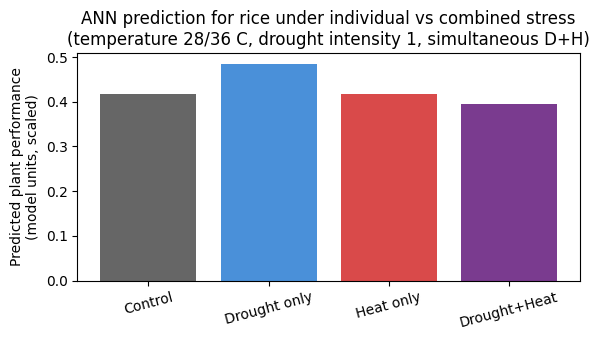

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(rice_pred["Treatment"], rice_pred["Predicted_Plant_Performance"],
       color=["#666666", "#4a90d9", "#d94a4a", "#7a3b8f"])
ax.set_ylabel("Predicted plant performance\n(model units, scaled)")
ax.set_title("ANN prediction for rice under individual vs combined stress\n"
             "(temperature 28/36 C, drought intensity 1, simultaneous D+H)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/rice_prediction.png", dpi=120)
plt.show()

## 8. Export results — 結果のエクスポート
Saves both prediction tables as CSV inside the Colab workspace for inspection or download. 予測結果を CSV として保存します。

In [ ]:
predictions.to_csv("/content/example_predictions.csv", index=False)
rice_pred.to_csv("/content/rice_predictions.csv", index=False)
print("Saved: /content/example_predictions.csv, /content/rice_predictions.csv")

Saved: /content/example_predictions.csv, /content/rice_predictions.csv


## 9. Interpretation and limitations — 解釈と限界

**What was verified here (this run):** the authors' published trained TANH model loads under their pinned Keras 3.4.1 and runs their documented inference flow on their own example input; predictions are compared against the authors' shipped reference output. The rice scenario illustrates the paper's central use case: predicting the impact of a stress combination that may lack experimental data (cf. paper Fig. 6 context: observed rice drought-heat combined-stress reductions of ~48% vs 34%/37% for individual stresses; our notebook prediction is model output only, not an experimental measurement).

**Limitations — 限界:**
- Inference only. Training reproduction is impossible from the repository as shipped: the README references `Combined_stress.ipynb`, `X_train.csv` and `y_train.csv`, which are **not present** in the repo tree (verified 2026-09-29). 学習の再現は、リポジトリに訓練データ/ノートブックが同梱されていないため範囲外です。
- A single example does not verify the paper's reported metrics (76.33% accuracy, 80.2% regression agreement, r = 0.915).
- The regression head outputs a min-max-scaled value; the paper reports % reductions. Interpret units as model-scaled performance.
- **Environment deviation:** the authors' README pins TensorFlow 2.17.0 / Keras 3.4.1 / scikit-learn 1.4.2 on Python 3.12; Colab's Python 3.13 runtime cannot install those versions. This notebook uses Colab's preinstalled stack and validates the result against the authors' shipped reference output instead (near-exact agreement observed 2026-09-29). 著者指定バージョンは Colab（Python 3.13）では導入不可のため、Colab 既定のスタックを使用し、著者同梱の参照出力との一致で検証しました。
- `study_flow` fields and API summaries are prior AI-generated research guidance, not primary proof; primary evidence here is the pinned author repository and its files.

**References:** paper DOI [10.1002/aps3.70047](https://doi.org/10.1002/aps3.70047); code https://github.com/scipdatabase/Prediction_model; SCIPDb https://db.nipgr.ac.in/plant_complete/downloads.php